# Capítulo 6: Análisis de Comportamiento de Usuarios (UBA) *(Versión Simulada)*

## 6.1. Fundamentos del UBA

Esta versión genera **5 usuarios simulados** con patrones de comportamiento diferenciados. Cada usuario tiene:
- Una **hora habitual de login** (distribución normal durante horario de oficina).
- **IPs corporativas habituales** (2 por usuario).
- **Volumen de datos** típico (distribución normal).
- Un número de **eventos sospechosos inyectados** (madrugada + IPs externas + volúmenes masivos).

---
## 6.2. Generación de datos simulados

In [1]:
import numpy as np
import pandas as pd
import os

np.random.seed(42)
os.makedirs('data', exist_ok=True)

usuarios = ['ana.garcia', 'carlos.lopez', 'maria.torres', 'juan.perez', 'lucia.diaz']
ips_corporativas = ['10.0.1.10', '10.0.1.11', '10.0.1.12', '10.0.1.20', '10.0.2.30']
ips_externas = ['45.33.32.156', '185.220.101.5', '91.219.236.10', '104.18.5.6']

registros = []
for usuario in usuarios:
    hora_base = np.random.uniform(7.5, 9.5)
    hora_std = np.random.uniform(0.3, 1.0)
    bytes_base = np.random.uniform(5000, 50000)
    bytes_std = np.random.uniform(2000, 15000)
    ips_habituales = np.random.choice(ips_corporativas, size=2, replace=False).tolist()

    for _ in range(200):
        registros.append({'user': usuario,
                          'hora_login': round(np.clip(np.random.normal(hora_base, hora_std), 0, 23.99), 2),
                          'ip_origen': np.random.choice(ips_habituales),
                          'bytes_sent': int(np.clip(np.random.normal(bytes_base, bytes_std), 100, 500000)),
                          'failed_logins': np.random.choice([0,0,0,0,1], p=[0.7,0.1,0.1,0.05,0.05])})

    for _ in range(np.random.randint(5, 11)):
        registros.append({'user': usuario,
                          'hora_login': round(np.random.uniform(0.5, 5.0), 2),
                          'ip_origen': np.random.choice(ips_externas),
                          'bytes_sent': int(np.random.uniform(300000, 900000000)),
                          'failed_logins': np.random.randint(3, 15)})

df_logs = pd.DataFrame(registros).sample(frac=1, random_state=42).reset_index(drop=True)
df_logs.to_csv('data/user_activity_logs.csv', index=False)
print(f"[OK] data/user_activity_logs.csv: {len(df_logs)} registros, {df_logs['user'].nunique()} usuarios")
df_logs.head()

[OK] data/user_activity_logs.csv: 1044 registros, 5 usuarios


,user,hora_login,ip_origen,bytes_sent,failed_logins
0,lucia.diaz,9.21,10.0.1.12,26575,0
1,carlos.lopez,7.95,10.0.1.12,35759,0
2,maria.torres,8.32,10.0.1.20,24520,0
3,juan.perez,8.82,10.0.1.12,12606,0
4,juan.perez,7.37,10.0.1.12,30146,0


---
## 6.3. Construcción de perfiles y detección de anomalías

In [2]:
# Listing 6.1: Modelado de comportamiento de usuario con estadísticas

def construir_perfil_usuario(logs, usuario):
    d = logs[logs['user'] == usuario]
    return {'usuario': usuario,
            'hora_media_login': d['hora_login'].mean(),
            'hora_std_login': d['hora_login'].std(),
            'ip_frecuentes': d['ip_origen'].value_counts().head(5).index.tolist(),
            'bytes_enviados_media': d['bytes_sent'].mean(),
            'bytes_enviados_std': d['bytes_sent'].std(),
            'accesos_fallidos_p95': d['failed_logins'].quantile(0.95),
            'total_registros': len(d)}

def detectar_comportamiento_anomalo(evento, perfil, umbral_z=3.0):
    alertas = []
    if perfil['hora_std_login'] > 0:
        z = abs((evento['hora_login'] - perfil['hora_media_login']) / perfil['hora_std_login'])
        if z > umbral_z:
            alertas.append(f"Hora inusual (z={z:.2f}): {evento['hora_login']}h")
    if evento['ip_origen'] not in perfil['ip_frecuentes']:
        alertas.append(f"IP no habitual: {evento['ip_origen']}")
    if (perfil['bytes_enviados_std'] > 0 and
        evento['bytes_sent'] > perfil['bytes_enviados_media'] + umbral_z * perfil['bytes_enviados_std']):
        alertas.append(f"Volumen inusual: {evento['bytes_sent']} bytes")
    return alertas

logs = pd.read_csv('data/user_activity_logs.csv')
perfiles = {u: construir_perfil_usuario(logs, u) for u in logs['user'].unique()}

print("=== Perfiles de Usuario ===")
for u, p in perfiles.items():
    print(f"{u:<20} hora_media={p['hora_media_login']:.2f}h  bytes_media={p['bytes_enviados_media']:.0f}")

=== Perfiles de Usuario ===
lucia.diaz           hora_media=8.82h  bytes_media=16400167
carlos.lopez         hora_media=7.75h  bytes_media=16434382
maria.torres         hora_media=7.84h  bytes_media=21126672
juan.perez           hora_media=8.26h  bytes_media=11994137
ana.garcia           hora_media=7.99h  bytes_media=15728159


In [3]:
# Análisis masivo y ejemplo de detección
perfil_ana = perfiles['ana.garcia']
evento_sospechoso = {'hora_login': 3.5, 'ip_origen': '45.33.32.156', 'bytes_sent': 500_000_000}
alertas = detectar_comportamiento_anomalo(evento_sospechoso, perfil_ana)
print(f"[!] ALERTAS para '{perfil_ana['usuario']}':")
for alerta in alertas:
    print(f"    ⚠ {alerta}")

# Análisis masivo
resultados = []
for _, row in logs.iterrows():
    al = detectar_comportamiento_anomalo({'hora_login': row['hora_login'],
                                          'ip_origen': row['ip_origen'],
                                          'bytes_sent': row['bytes_sent']}, perfiles[row['user']])
    resultados.append({'user': row['user'], 'es_anomalo': 1 if al else 0, 'num_alertas': len(al)})
df_res = pd.DataFrame(resultados)
print(f"\nTotal anomalías detectadas: {df_res['es_anomalo'].sum()} / {len(df_res)}")
print(df_res[df_res['es_anomalo']==1].groupby('user')['es_anomalo'].count())

[!] ALERTAS para 'ana.garcia':
    ⚠ Hora inusual (z=3.13): 3.5h
    ⚠ Volumen inusual: 500000000 bytes

Total anomalías detectadas: 40 / 1044
user
ana.garcia       7
carlos.lopez     8
juan.perez       5
lucia.diaz      10
maria.torres    10
Name: es_anomalo, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22700\2592396393.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=logs, x='user', y='hora_login', ax=axes[0], palette='Set2')


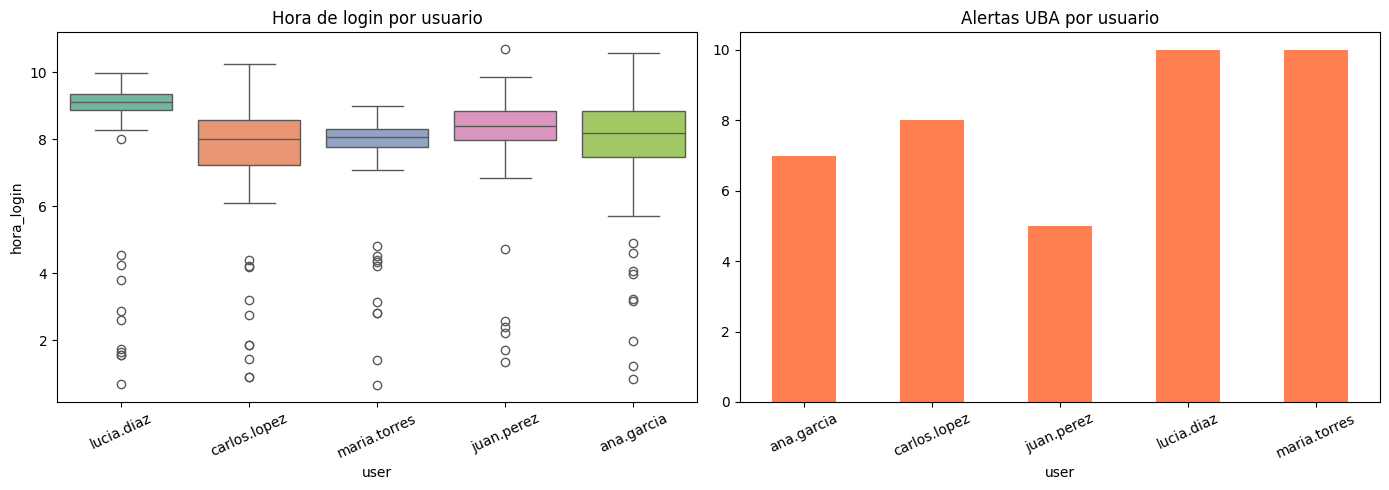

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=logs, x='user', y='hora_login', ax=axes[0], palette='Set2')
axes[0].set_title('Hora de login por usuario')
axes[0].tick_params(axis='x', rotation=25)

alertas_por_usuario = df_res[df_res['es_anomalo']==1].groupby('user')['es_anomalo'].count()
alertas_por_usuario.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Alertas UBA por usuario')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('data/uba_analysis.png', dpi=150)
plt.show()

## 6.4. Guardado de artefactos

In [5]:
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(perfiles, 'models/user_profiles.pkl')
print("[OK] models/user_profiles.pkl")

[OK] models/user_profiles.pkl
